**Diabetes Variables Table**
[link text](https://northeastern-my.sharepoint.com/:x:/g/personal/hu_junhu_northeastern_edu/EWB6GLxecKRGsDpVkeL7J_0B3fHzP9fEO0HNndf6x3QfBg?e=Vi4KTS)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from tkinter import Tk
from tkinter.filedialog import askopenfilename

# Open file dialog
Tk().withdraw()  # Prevents the root window from appearing
file_path = askopenfilename(title="Select your CSV file", filetypes=[("CSV files", "*.csv")])

# Load the file
df = pd.read_csv(file_path)
print(f"Loaded file: {file_path}")
df.head()

Loaded file: /Users/sahilniranjan/Desktop/ALY 6040/DataSET/diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Data cleaning**

In [23]:
print("rows", df.shape[0])
print("columns", df.shape[1])

rows 101766
columns 50


In [24]:
df.head()

# Display data types and build a basic data dictionary
df.info()

# Now create the data dictionary as shown before
col_descriptions = {
    "encounter_id": "Unique identifier for each hospital encounter",
    "patient_nbr": "Unique patient identifier (anonymized)",
    "race": "Patient's self-reported race",
    "gender": "Patient's gender",
    "age": "Patient's age group (range)",
    "admission_type_id": "Type of hospital admission (numeric code)",
    "discharge_disposition_id": "Patient discharge status (numeric code)",
    "admission_source_id": "Source of admission (numeric code)",
    "time_in_hospital": "Length of hospital stay (days)",
    "payer_code": "Primary payment source (insurance type)",
    "medical_specialty": "Primary medical specialty of admitting physician",
    "num_lab_procedures": "Number of lab procedures performed",
    "num_procedures": "Number of procedures (other than lab tests) performed",
    "num_medications": "Number of medications administered",
    "number_outpatient": "Number of outpatient visits in the year prior",
    "number_emergency": "Number of emergency visits in the year prior",
    "number_inpatient": "Number of inpatient visits in the year prior",
    "diag_1": "Primary diagnosis (ICD-9 code)",
    "diag_2": "Secondary diagnosis (ICD-9 code)",
    "diag_3": "Additional diagnosis (ICD-9 code)",
    "number_diagnoses": "Number of diagnoses for the encounter",
    "max_glu_serum": "Maximum glucose serum test result",
    "A1Cresult": "A1C test result",
    "metformin": "Metformin usage (up/down/steady/no)",
    "insulin": "Insulin usage (up/down/steady/no)",
    "change": "Change in diabetic medications (yes/no)",
    "diabetesMed": "Whether any diabetic medication was prescribed",
    "readmitted": "Outcome: Patient readmitted or not",
    "readmitted_binary": "Binary: 1 if readmitted within 30 days, else 0"
}

data_dict = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.astype(str),
    'Description': [col_descriptions.get(col, "Description not provided") for col in df.columns]
})

data_dict


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,Column,Type,Description
encounter_id,encounter_id,int64,Unique identifier for each hospital encounter
patient_nbr,patient_nbr,int64,Unique patient identifier (anonymized)
race,race,object,Patient's self-reported race
gender,gender,object,Patient's gender
age,age,object,Patient's age group (range)
weight,weight,object,Description not provided
admission_type_id,admission_type_id,int64,Type of hospital admission (numeric code)
discharge_disposition_id,discharge_disposition_id,int64,Patient discharge status (numeric code)
admission_source_id,admission_source_id,int64,Source of admission (numeric code)
time_in_hospital,time_in_hospital,int64,Length of hospital stay (days)


In [25]:
#replace '?' to NA
df.replace('?', np.nan, inplace=True)

In [26]:
# make a table to show missing percent
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})
missing_summary[missing_summary['Missing Count'] > 0]
#df.head()

#delete high missing rate column over which 50%
missing_rate = df.isnull().mean().sort_values(ascending=False)
high_missing_cols = missing_rate[missing_rate > 0.5].index
df.drop(columns=high_missing_cols, inplace=True)
#print(df.isnull().sum())

In [27]:
# Summary statistics and dataset structure
print(len(df))
print(df.describe())
print("\n Number of unique values in categorical columns")
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].nunique()} ")

101766
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%                    1.000000             

duplicate rows 0


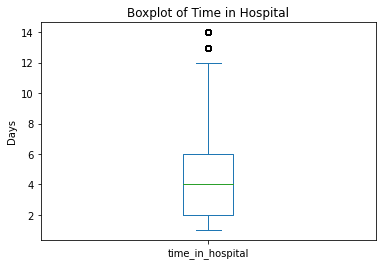

In [28]:
# Check for duplicates and time in hospital outliers
print("duplicate rows", df.duplicated().sum())

# Use a boxplot to identify potential outliers in 'time_in_hospital'
import matplotlib.pyplot as plt
df['time_in_hospital'] = df['time_in_hospital'].astype(int)
df['time_in_hospital'].plot(kind='box')
plt.title('Boxplot of Time in Hospital')
plt.ylabel('Days')
plt.show()

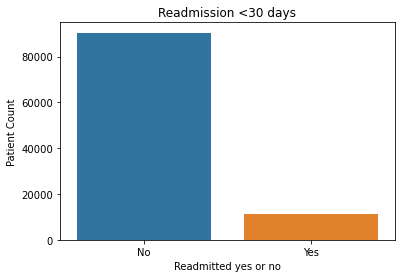

In [29]:
######### Simplify readmitted to binary: <30 as 1, others as 0 ##################
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)


# Visualize
import seaborn as sns
sns.countplot(x='readmitted_binary', data=df)
plt.title('Readmission <30 days')
plt.xticks([0,1], ['No', 'Yes'])
plt.xlabel('Readmitted yes or no')
plt.ylabel('Patient Count')
plt.show()

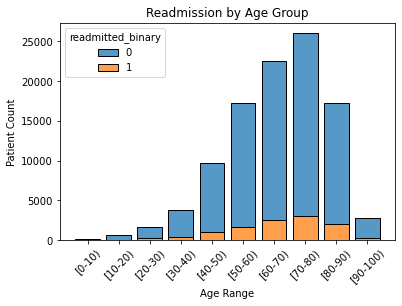

In [30]:
# Readmission by age group
sns.histplot(data=df, x='age', hue='readmitted_binary', multiple='stack', shrink=0.8)
plt.title('Readmission by Age Group')
plt.xlabel('Age Range')
plt.ylabel('Patient Count')
plt.xticks(rotation=45)
plt.show()

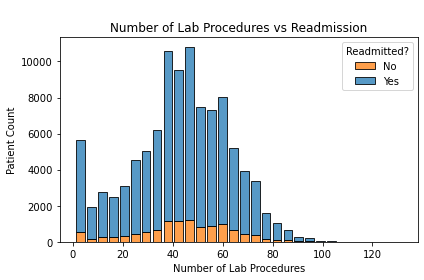

In [31]:
# Number of lab procedures vs readmission
sns.histplot(data=df, x='num_lab_procedures', hue='readmitted_binary', multiple='stack', bins=30, shrink=0.8)
plt.title('\nNumber of Lab Procedures vs Readmission')
plt.xlabel('Number of Lab Procedures')
plt.ylabel('Patient Count')
plt.legend(title='Readmitted?', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

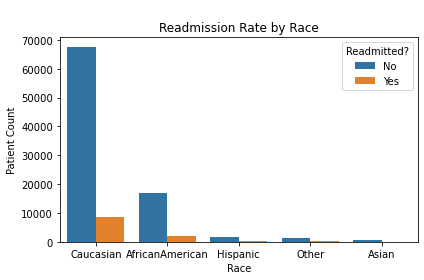

In [32]:
# Readmission rate by race
sns.countplot(data=df, x='race', hue='readmitted_binary', order=df['race'].value_counts().index)
plt.title('\nReadmission Rate by Race')
plt.xlabel('Race')
plt.ylabel('Patient Count')
plt.legend(title='Readmitted?', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

In [33]:
# calculate readmission rate by Primary diagnosis code
top_diag = (
    df.groupby('diag_1')['readmitted_binary']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'patient', 'mean': 'readmission'})
    .sort_values('patient', ascending=False)
    .head(10)
)
print(top_diag)

        patient  readmission
diag_1                      
428        6862     0.141067
414        6581     0.090412
786        4016     0.072460
410        3614     0.103210
486        3508     0.089510
427        2766     0.091106
491        2275     0.126154
715        2151     0.099954
682        2042     0.089618
434        2028     0.162229


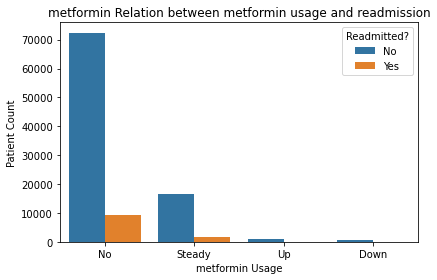

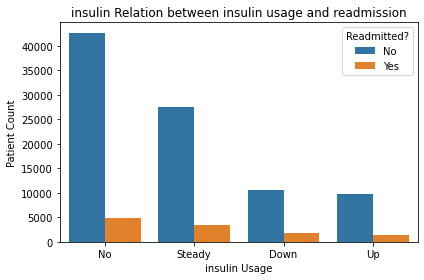

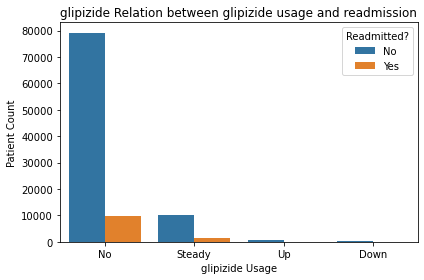

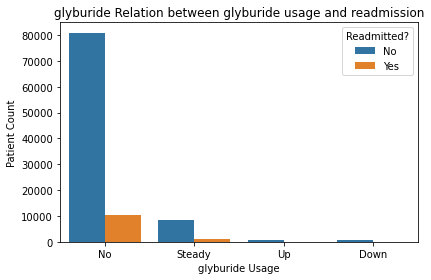

In [34]:
#Medication usage and readmission
drug_cols = ['metformin', 'insulin', 'glipizide', 'glyburide']
#Visualize
for col in drug_cols:
    sns.countplot(data=df, x=col, hue='readmitted_binary', order=df[col].value_counts().index)
    plt.title(f"{col} Relation between {col} usage and readmission")
    plt.xlabel(f'{col} Usage')
    plt.ylabel('Patient Count')
    plt.legend(title='Readmitted?', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

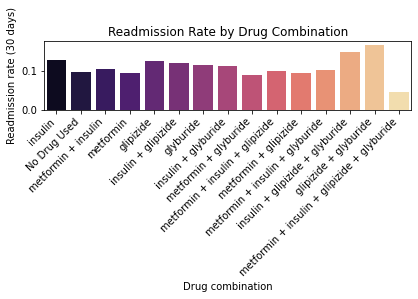

In [35]:
drug_cols = ['metformin', 'insulin', 'glipizide', 'glyburide']
# generate combination labels based on actual usage
def generate_label(row):
    used_drugs = [drug for drug in drug_cols if row[drug].lower() in ['up', 'down', 'steady']]
    return ' + '.join(used_drugs) if used_drugs else 'No Drug Used'

# Create the label column
df['drug_combination'] = df.apply(generate_label, axis=1)

# Group by the new drug combination label
combo_summary = (
    df.groupby('drug_combination')['readmitted_binary']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'patient_count', 'mean': 'readmission_rate'})
    .reset_index()
)
#select top15
top_combos = combo_summary.sort_values('patient_count', ascending=False).head(15)

# Plot the results
sns.barplot(data=top_combos, x='drug_combination', y='readmission_rate', palette='magma')
plt.title('Readmission Rate by Drug Combination')
plt.xlabel('Drug combination')
plt.ylabel('Readmission rate (30 days)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()